# Bank Marketing Subscription Prediction
End-to-end classification project focused on realistic CRM deployment and data leakage prevention.

## Import Libraries

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve, recall_score
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
import shap

import warnings
warnings.filterwarnings('ignore')

## Load Data and Initial Exploration

In [ ]:
df = pd.read_csv('/content/bank-marketing-subscription-model/data/bank.csv')

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [ ]:
# target map
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})

In [ ]:
print(f"Dimension of dataset: {df.shape}\n")
print(f"Missing Values: \n{df.isnull().sum()}\n")

Dimension of dataset: (11162, 17)

Missing Values: 
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64



The dataset contains 11,162 observations and 17 features.

No missing values were detected across all features.

## Exploratory Data Analysis (EDA)

### Target Distribution

Understanding the distribution of the target variable is crucial to assess potential class imbalance.

In [ ]:
df['deposit'].value_counts(normalize=True).round(3)*100

,proportion
deposit,
0,52.6
1,47.4


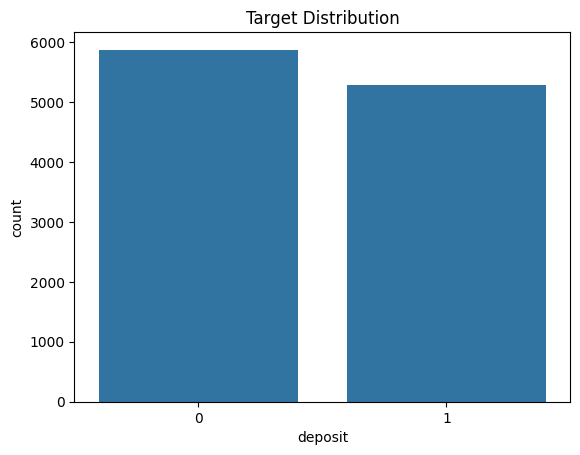

In [ ]:
sns.countplot(x='deposit', data=df)
plt.title("Target Distribution")
plt.show()

The dataset is moderately imbalanced, with a larger proportion of customers not subscribing to the term deposit.

This imbalance suggests that accuracy alone may not be a sufficient evaluation metric, and additional metrics such as precision, recall, and ROC-AUC should be considered.

### Numerical Features Analysis

We analyze the distribution of numerical variables to identify skewness, outliers, and potential issues affecting model performance.

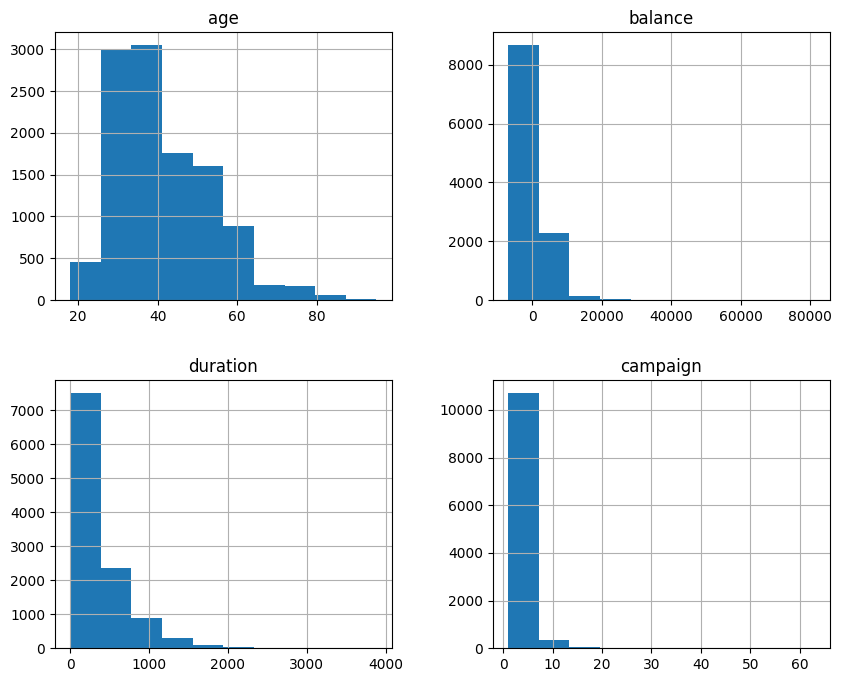

In [ ]:
df[['age', 'balance', 'duration', 'campaign']].hist(figsize=(10,8))
plt.show()

- Age is relatively well distributed, with most customers between 30 and 50 years old.\
This suggests age may not require transformation or binning.
- Balance is highly right-skewed, indicating the presence of customers with very high account balances.
- Duration shows strong skewness, with most calls being short and a few significantly longer.
- Campaign is concentrated around low values, suggesting that most customers are contacted only a few times.

#### Outlier Analysis

Boxplots are used to detect extreme values and better understand the distribution of key numerical features.

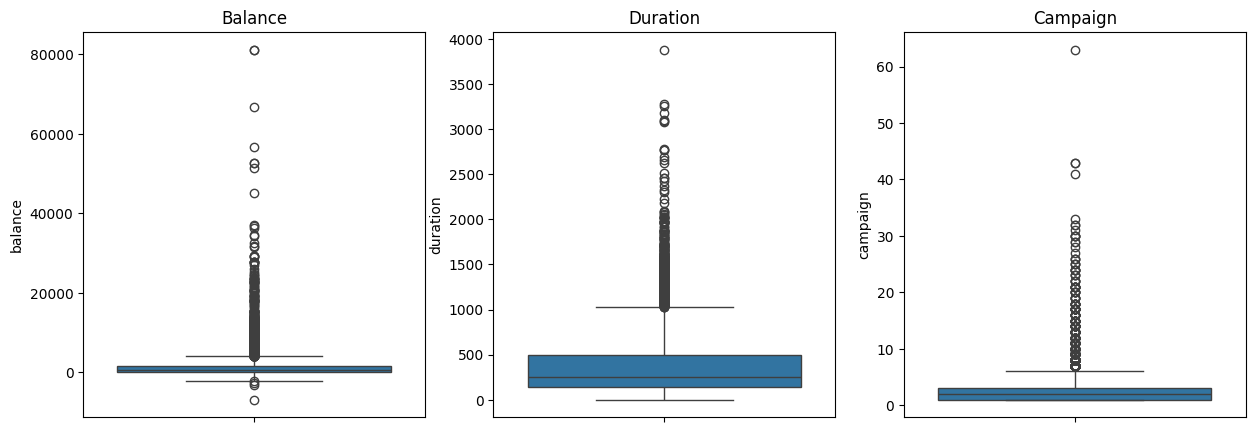

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.boxplot(y=df['balance'], ax=axes[0])
axes[0].set_title("Balance")

sns.boxplot(y=df['duration'], ax=axes[1])
axes[1].set_title("Duration")

sns.boxplot(y=df['campaign'], ax=axes[2])
axes[2].set_title("Campaign")

plt.show()

- Balance contains significant outliers, likely representing high net-worth customers rather than errors.
- Duration also presents extreme values, corresponding to unusually long calls.
- Campaign shows some extreme cases where customers were contacted many times.

These observations suggest that removing outliers may not be appropriate, and robust models (e.g., tree-based models) will be preferred, since they are less sensitive to skewness and outliers compared to linear models.

### Categorical Features vs Target

We analyze how categorical variables relate to the target variable to identify patterns and potential predictive features.

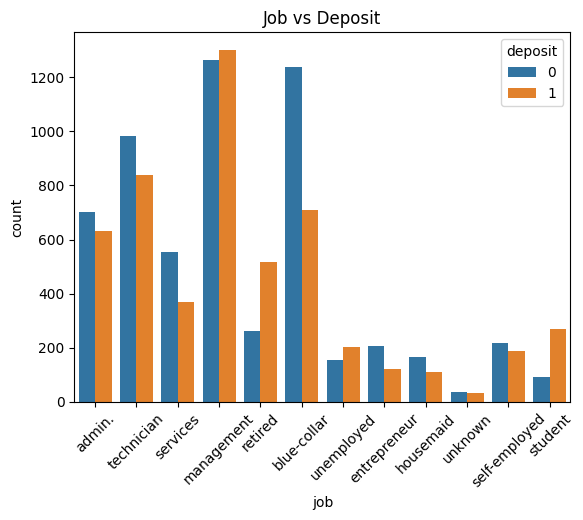

In [ ]:
sns.countplot(x='job', hue='deposit', data=df)
plt.xticks(rotation=45)
plt.title("Job vs Deposit")
plt.show()

The job category shows clear differences in subscription behavior.

Students and retired customers tend to have a higher subscription rate, while blue-collar and services workers show lower engagement.

This suggests that occupation plays a significant role in customer behavior and could be an important predictive feature.

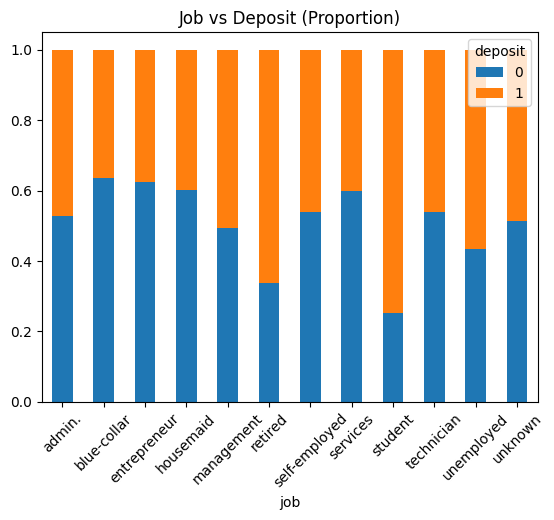

In [ ]:
pd.crosstab(df['job'], df['deposit'], normalize='index').plot(kind='bar', stacked=True)
plt.xticks(rotation=45)
plt.title("Job vs Deposit (Proportion)")
plt.show()

When analyzing proportions, differences between categories become clearer.

Some job categories show a significantly higher probability of subscription, reinforcing the importance of customer segmentation.

### Data Leakage Consideration

The feature "duration" represents the length of the call.

This variable is not available at the time of prediction, as it is only known after the call has occurred.

Including it in the model would introduce data leakage and result in overly optimistic performance.

Therefore, we will:
- build an initial model including duration (for reference)
- build a final model excluding duration (realistic scenario)

## Preprocessing

In this stage, we prepare the raw dataset for the machine learning pipeline. The preprocessing steps include:
* **Categorical Encoding**: Converting non-numeric variables into a machine-readable format using techniques like One-Hot Encoding.
* **Feature Scaling**: Standardizing numerical features to ensure they contribute equally to the model's distance-based calculations.
* **Data Leakage Mitigation**: Identifying and handling variables like `duration`, which are not known at the time of prediction, to ensure the model's validity in a production environment.

In [ ]:
class CustomPreprocessor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        if 'pdays' in X.columns:
            X['pdays'] = X['pdays'].replace(-1, 0)

        if 'balance' in X.columns:
            X['balance'] = X['balance'].clip(lower=0)

        return X

In [ ]:
def preprocessing_pipeline(df, model_scenario):
    df = df.copy()

    if model_scenario == "WITHOUT DURATION":
        X = df.drop(columns=['deposit', 'duration'])
    else: # "WITH DURATION"
        X = df.drop(columns='deposit')

    y = df['deposit']

    # train val test split
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

    # Dynamically determine numerical and categorical features from the processed X_train split
    num_features = X_train.select_dtypes(include=np.number).columns.tolist()
    cat_features = X_train.select_dtypes(include='object').columns.tolist()

    # log transformation for skewed data
    log_transformer = FunctionTransformer(np.log1p,
                                          feature_names_out="one-to-one",
                                          validate=False)

    # numerical pipeline
    num_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')),
                                ('log', log_transformer),
                                ('scaler', StandardScaler())])

    # categorical pipeline
    cat_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

    # column pipeline
    col_transformer = ColumnTransformer(
                          transformers=[('num', num_transformer, num_features),
                                        ('cat', cat_transformer, cat_features)],
                          remainder='drop')
    # complete preprocessing pipeline
    preprocessor = Pipeline([('custom', CustomPreprocessor()),
                              ('column', col_transformer)])

    return X_train, X_val, X_test, y_train, y_val, y_test, preprocessor

## Models

In this section, we train and evaluate classification models to predict whether a customer will subscribe to a term deposit.

Two scenarios are considered:
- a model including the "duration" feature (for reference)
- a model excluding "duration" to simulate a realistic use case and avoid data leakage

In [ ]:
def train_validate_test(X_train, X_val, X_test, y_train, y_val, y_test, preprocessor_obj, model_name):

    # 1. Pipeline Logistic Regression
    pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor_obj),
                                  ('model', LogisticRegression(max_iter=1000,
                                                               random_state=42,
                                                               class_weight='balanced'))])

    # 2. Pipeline Random Forest
    pipeline_rf_base = Pipeline(steps=[('preprocessor', preprocessor_obj),
                                       ('model', RandomForestClassifier(random_state=42))])

    # 3. Hyperparameter grid
    param_grid_rf = {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5],
        'model__class_weight': ['balanced', None]}

    # 4. Train Logistic Regression
    pipeline_lr.fit(X_train, y_train)

    # 5. Grid Search RF
    print(f"\nExecution of Grid Search for Random Forest ({model_name})...")
    grid_search_rf = GridSearchCV(estimator=pipeline_rf_base,
                                  param_grid=param_grid_rf,
                                  cv=5,
                                  scoring='roc_auc',
                                  n_jobs=-1)
    grid_search_rf.fit(X_train, y_train)

    pipeline_rf = grid_search_rf.best_estimator_

    # ===== VALIDATION =====
    y_val_prob_lr = pipeline_lr.predict_proba(X_val)[:, 1]
    y_val_prob_rf = pipeline_rf.predict_proba(X_val)[:, 1]

    print(f"\n===== {model_name} - VALIDATION ====")

    roc_lr = roc_auc_score(y_val, y_val_prob_lr)
    roc_rf = roc_auc_score(y_val, y_val_prob_rf)

    print("\nLogistic Regression")
    print("ROC-AUC:", round(roc_lr, 3))

    print("\nRandom Forest (Tuned)")
    print("ROC-AUC:", round(roc_rf, 3))
    print("Best params:", grid_search_rf.best_params_)

    # Model selection
    if roc_rf > roc_lr:
        best_pipeline = pipeline_rf
        best_name = "Random Forest (Tuned)"
        y_val_prob = y_val_prob_rf
    else:
        best_pipeline = pipeline_lr
        best_name = "Logistic Regression"
        y_val_prob = y_val_prob_lr

    print(f"\nBest model on validation: {best_name}")

    # ===== CROSS-VALIDATION (robustness check) =====
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(best_pipeline,
                                X_train,
                                y_train,
                                cv=cv,
                                scoring='roc_auc',
                                n_jobs=-1)

    print("\nCross-Validation ROC-AUC:", round(cv_scores.mean(), 3),
          "+/-", round(cv_scores.std(), 3))

    # ===== THRESHOLD TUNING =====
    precision, recall, thresholds = precision_recall_curve(y_val, y_val_prob)

    target_recall = 0.75
    default_recall = recall_score(y_val, (y_val_prob >= 0.5).astype(int))

    if default_recall > target_recall:
      best_t = 0.5
      print("\nDefault threshold already satisfies recall constraint.")

    else:
      candidates = [
          (p, r, t) for p, r, t in zip(precision, recall, list(thresholds)+[1.0])
          if r >= target_recall]

      if candidates:
            best_p, best_r, best_t = max(candidates, key=lambda x: x[0])
      else:
            best_t = 0.5

    print(f"\nChosen threshold: {round(best_t,3)}")

    # ===== TEST =====
    y_test_prob = best_pipeline.predict_proba(X_test)[:, 1]
    y_test_pred_default = best_pipeline.predict(X_test)
    y_test_pred_custom = (y_test_prob >= best_t).astype(int)

    print(f"\n===== TEST PERFORMANCE ({best_name}) =====")

    print("\n--- Default threshold (0.5) ---")
    print(classification_report(y_test, y_test_pred_default))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_test_prob), 3))

    print("\n--- Custom threshold ---")
    print(classification_report(y_test, y_test_pred_custom))

    return best_pipeline, best_t

**Evaluation Strategy**

The dataset was split into training, validation, and test sets.
- Training set (60%) used to train the models
- Validation set (20%) used to compare model performance and select the best model
- Test set (20%) used for the final evaluation

This approach ensures that model selection is performed independently from the final evaluation, providing a more reliable estimate of real-world performance.

### With duration

In [ ]:
X_train_wd, X_val_wd, X_test_wd, y_train_wd, y_val_wd, y_test_wd, preprocessor_wd = preprocessing_pipeline(df, "WITH DURATION")

In [ ]:
best_pipeline_with_duration, threshold = train_validate_test(X_train_wd, X_val_wd, X_test_wd,
                                                  y_train_wd, y_val_wd, y_test_wd,
                                                  preprocessor_wd,
                                                  "WITH DURATION");


Execution of Grid Search for Random Forest (WITH DURATION)...

===== WITH DURATION - VALIDATION ====

Logistic Regression
ROC-AUC: 0.906

Random Forest (Tuned)
ROC-AUC: 0.923
Best params: {'model__class_weight': None, 'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best model on validation: Random Forest (Tuned)

Cross-Validation ROC-AUC: 0.917 +/- 0.006

Default threshold already satisfies recall constraint.

Chosen threshold: 0.5

===== TEST PERFORMANCE (Random Forest (Tuned)) =====

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1175
           1       0.83      0.88      0.85      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233

ROC-AUC: 0.918

--- Custom threshold ---
              precision    recall  f1-score   support

           0     

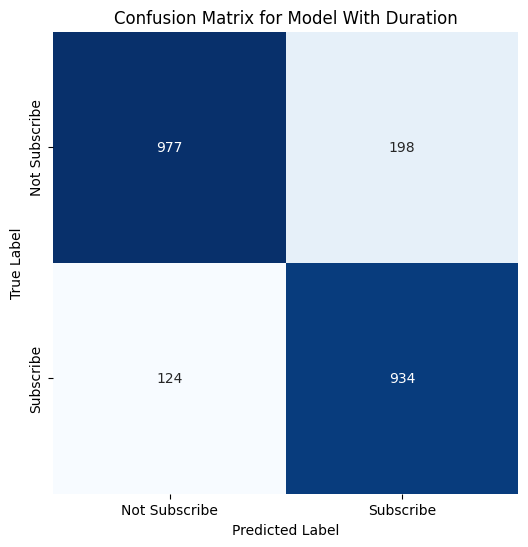

In [ ]:
# Predict on the test set using the best pipeline (with duration)
y_proba_wd = best_pipeline_with_duration.predict_proba(X_test_wd)[:, 1]
y_pred_wd = (y_proba_wd >= threshold).astype(int)

# Generate the confusion matrix
cm = confusion_matrix(y_test_wd, y_pred_wd)

# Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Subscribe', 'Subscribe'],
            yticklabels=['Not Subscribe', 'Subscribe'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Model With Duration')
plt.show()

#### Validation results

We compared **Logistic Regression** and **Random Forest** using the validation set to determine which algorithm better captures the underlying patterns of the dataset.

* **Logistic Regression**: Achieved a ROC-AUC of **0.906**.
* **Random Forest**: Achieved a superior ROC-AUC of **0.923**.

The Random Forest model outperformed Logistic Regression, likely due to its ability to model complex non-linear interactions between features. Consequently, **Random Forest** was selected as the final model for this scenario.

#### Evaluation results

The selected Random Forest model was evaluated on the unseen test set to estimate its generalization capabilities.

The results are highly promising:
* **ROC-AUC**: 0.918
* **Overall Accuracy**: 86%
* **Class 1 (Subscribers) Recall**: 0.88, indicating the model identifies 88% of potential customers.
* **Class 1 Precision**: 0.83, showing a low rate of false positives.

While these metrics suggest an excellent predictive power, they must be interpreted within the context of the features used.

This confusion matrix indicates a strong performance.

- It is very good at identifying actual subscribers (TP = 934) and actual non-subscribers (TN = 977).
- The number of False Negatives (124) is relatively low, meaning it doesn't miss many potential subscribers.\
This aligns with the high recall (0.88) for the positive class (subscribers) that we observed earlier.
- The number of False Positives (198) is also manageable, suggesting that when the model predicts a subscription, it's often correct.\
This corresponds to the good precision (0.83) for the positive class.

Overall, this confusion matrix confirms the high performance metrics previously seen for this model, but as mentioned, it benefits from the duration feature, which leads to data leakage in a real-world predictive scenario.

#### Threshold Optimization

Threshold tuning was applied using the validation set to explore the trade-off between precision and recall.

Although higher thresholds increase precision, they also reduce recall significantly.

In this case, the default threshold (0.5) already achieves a high recall, which is crucial for the business objective of identifying potential subscribers.

#### Limitation: Data Leakage

Although the performance metrics above are statistically high, they are functionally flawed for real-world deployment.

The inclusion of the **`duration`** feature (call length) introduces **Data Leakage**. In a real-world predictive scenario, the duration of a call is only known *after* the call has concluded. Therefore, using it to predict whether a customer *will* subscribe (before the call is made) is impossible.

This version of the model serves only as a benchmark. To create a deployable tool, we must evaluate a version that excludes all post-interaction variables.

### Realistic Model (Without Duration)

In this section, we train and evaluate the models after removing the `duration` feature.

From a business perspective, this is the only valid approach for a predictive tool.\
The goal is to identify potential subscribers *before* the call is made, using only demographic data, social-economic indicators, and previous marketing history.\
This ensures the model is not "cheating" by using information that is only generated during the conversation itself.

In [ ]:
X_train_nd, X_val_nd, X_test_nd, y_train_nd, y_val_nd, y_test_nd, preprocessor_nd = preprocessing_pipeline(df, "WITHOUT DURATION")

In [ ]:
best_pipeline_without_duration, threshold = train_validate_test(X_train_nd, X_val_nd, X_test_nd,
                                                     y_train_nd, y_val_nd, y_test_nd,
                                                     preprocessor_nd,
                                                     "WITHOUT DURATION")


Execution of Grid Search for Random Forest (WITHOUT DURATION)...

===== WITHOUT DURATION - VALIDATION ====

Logistic Regression
ROC-AUC: 0.772

Random Forest (Tuned)
ROC-AUC: 0.785
Best params: {'model__class_weight': None, 'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best model on validation: Random Forest (Tuned)

Cross-Validation ROC-AUC: 0.786 +/- 0.011

Chosen threshold: 0.414

===== TEST PERFORMANCE (Random Forest (Tuned)) =====

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

           0       0.69      0.84      0.76      1175
           1       0.76      0.59      0.67      1058

    accuracy                           0.72      2233
   macro avg       0.73      0.71      0.71      2233
weighted avg       0.73      0.72      0.72      2233

ROC-AUC: 0.773

--- Custom threshold ---
              precision    recall  f1-score   support

           0       0.73      0.70      0.72      1175
           

The performance on the validation set shows a significant but expected decrease compared to the model with leakage.

- **Logistic Regression** achieved a ROC-AUC of **0.772**
- **Random Forest** achieved a superior ROC-AUC of **0.785**

In this scenario, Random Forest shows a better performance and is selected as our final realistic model for testing.

The model trained without the "duration" feature represents a realistic scenario, as this variable is not available at prediction time.

Both models show moderate predictive power:
- Logistic Regression achieves a ROC-AUC of approximately 0.77  
- Random Forest performs slightly better, confirming its ability to capture non-linear relationships

However, performance is significantly lower compared to the model including duration, highlighting the strong predictive power of that variable and the impact of removing data leakage.

Using the default threshold (0.5), the model achieves a recall of **0.59** for the positive class (subscribers), indicating that a substantial number of potential customers are not correctly identified.

To address this limitation, threshold tuning was applied using the validation set.

By lowering the threshold to **0.414**, the model improves recall to **0.72**, significantly increasing its ability to identify potential subscribers.\
This comes with a reduction in precision, but the trade-off is acceptable in a marketing context, where missing a potential customer (false negative) is more costly than contacting a non-interested one (false positive).

This result highlights that, even with moderate model performance, proper threshold optimization can substantially improve the practical effectiveness of the model.

Overall, predicting customer behavior using only pre-contact features remains a challenging task, but the model provides a useful and actionable approximation when combined with appropriate decision threshold tuning.

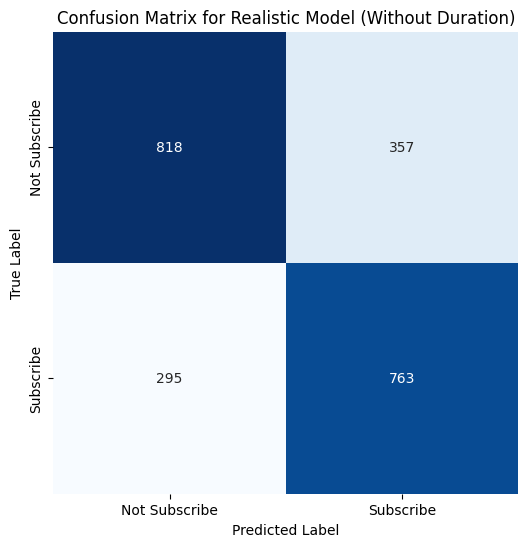

In [ ]:
# Predict on the test set using the best pipeline (without duration)
y_proba_nd = best_pipeline_without_duration.predict_proba(X_test_nd)[:, 1]
y_pred_nd = (y_proba_nd >= threshold).astype(int)

# Generate the confusion matrix
cm = confusion_matrix(y_test_nd, y_pred_nd)

# Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Subscribe', 'Subscribe'],
            yticklabels=['Not Subscribe', 'Subscribe'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Realistic Model (Without Duration)')
plt.show()

Plotting the confusion matrix for the 'realistic' model (without 'duration') on the test set we can see that:

- **True Negatives** (818): The model correctly predicted 818 customers would not subscribe.
- **False Positives** (357): The model incorrectly predicted 357 customers would subscribe, but they did not.
- **False Negatives** (295): The model incorrectly predicted 295 customers would not subscribe, but they did (missed opportunities).
- **True Positives** (763): The model correctly predicted 763 customers would subscribe.

The model is reasonably good at identifying non-subscribers but struggles more with false negatives, meaning it misses a significant number of potential subscribers. This aligns with the recall for the positive class (0.72) previously noted.

### Model Comparison: With vs Without Duration


The inclusion of "duration" creates a data leakage scenario because the length of a call is only known after the contact has occurred, making it unavailable for real-time predictive modeling.

- **Recall Gap**: Without duration, the recall for the positive class (1) drops from 0.88 to 0.72, showing that identifying potential subscribers becomes much harder without knowing the call length.

- **Model Selection**: In both scenarios the Random Forest is identified as best model.

The model without duration is the only one suitable for deployment.\
The significant drop in metrics confirms that while "duration" is a powerful predictor, it provides an overly optimistic and non-actionable view of the model's true predictive power in a real-world setting.

## Feature Importance

To understand the model behavior, feature importance is evaluated using SHAP (SHapley Additive exPlanations).

SHAP provides a consistent framework to measure the contribution of each feature to the model’s predictions. Unlike traditional importance metrics, it:
- captures both the magnitude and direction of feature effects
- provides a global and local interpretation of the model
- is model-agnostic and grounded in game theory

In this analysis, we focus on the contribution of each feature to the prediction of the positive class (subscription = 1).

In [ ]:
model = best_pipeline_without_duration.named_steps['model']
preprocessor = best_pipeline_without_duration.named_steps['preprocessor']

X_test_transformed = preprocessor.transform(X_test_nd)
feature_names = preprocessor.named_steps['column'].get_feature_names_out()

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

In [ ]:
np.shape(shap_values)

(2233, 50, 2)

In [ ]:
shap_values_pos = shap_values[:,:,1]

#### SHAP summary plot

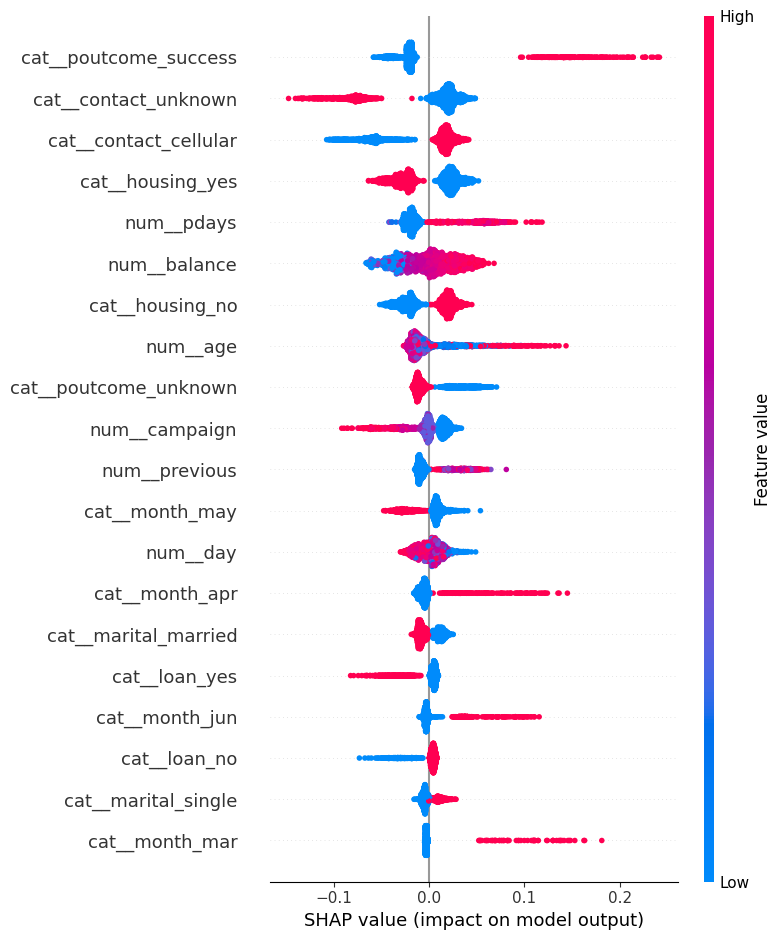

In [ ]:
# beeswarm plot
shap.summary_plot(shap_values_pos,
                  X_test_transformed,
                  feature_names=feature_names)

The summary plot displays the distribution of SHAP values for each feature across all observations.

Each point represents a single prediction:
- the x-axis shows the impact on the model output
- color indicates the feature value (red = high, blue = low)

Interpretation:
- positive SHAP values increase the probability of subscription
- negative SHAP values decrease it

This visualization highlights both the importance of each feature and how its values influence the prediction.

#### Global Feature Importance

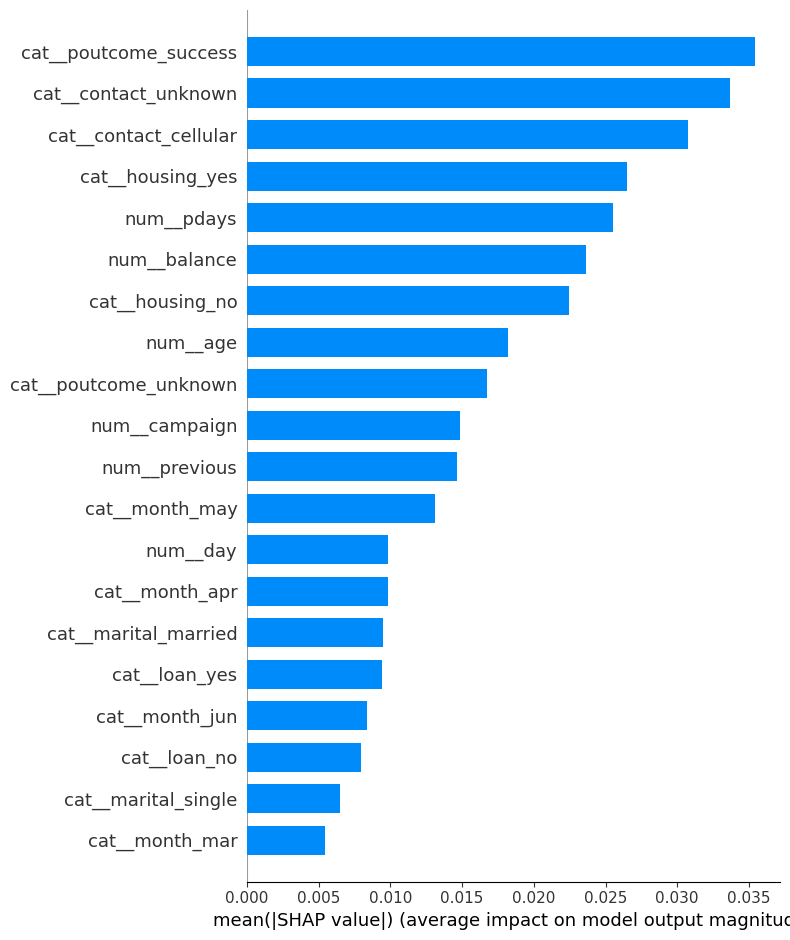

In [ ]:
# bar plot
shap.summary_plot(shap_values_pos,
                  X_test_transformed,
                  feature_names=feature_names,
                  plot_type="bar")

The bar plot shows the global importance of features, computed as the mean absolute SHAP value.

The most important features in the model are:

1. poutcome_success  
2. contact_unknown  
3. contact_cellular  
4. housing_yes  
5. pdays  
6. balance  
7. housing_no  
8. age  
9. poutcome_unknown  
10. campaign  

These variables have the strongest overall impact on the model’s predictions.

#### Interpretation of Key Features

In [ ]:
# importance table
shap_importance = np.abs(shap_values_pos).mean(axis=0)

shap_df = pd.DataFrame({"feature": feature_names,
                        "shap_importance": shap_importance}).sort_values("shap_importance",
                                                                         ascending=False)

shap_df.head(10)

,feature,shap_importance
48,cat__poutcome_success,0.035400
33,cat__contact_unknown,0.033703
31,cat__contact_cellular,0.030722
28,cat__housing_yes,0.026503
4,num__pdays,0.025545
1,num__balance,0.023641
27,cat__housing_no,0.022443
0,num__age,0.018211
49,cat__poutcome_unknown,0.016750
3,num__campaign,0.014846


- **poutcome_success**:
The most important feature. A successful previous campaign strongly increases the likelihood of subscription.

- **contact (unknown / cellular)**:
  The communication channel significantly affects the prediction. Some channels provide more reliable signals than others.

- **housing (yes/no)**:
  Reflects the financial condition of the client and influences their propensity to subscribe.

- **pdays**:
  Captures the recency of previous contacts. More recent interactions are generally more effective.

- **balance**:
  Indicates financial capacity. Higher balances are associated with higher subscription probability.

- **age**:
  Shows a non-linear relationship with the target, suggesting behavioral differences across age groups.

- **campaign**:
  A higher number of contacts may indicate diminishing returns and reduced campaign effectiveness.

##### Key Insights

The SHAP analysis reveals that:

- previous campaign outcomes are the strongest predictors
- customer interaction history plays a central role
- the communication channel significantly influences success
- excessive contact attempts may reduce effectiveness

Overall, the model relies primarily on **behavioral and historical information**, rather than purely demographic variables.

## Final Conclusions

This project aimed to develop and evaluate a predictive model for customer subscription behavior using a bank marketing dataset. Two modeling scenarios were considered: one including the `duration` variable and one excluding it, in order to simulate a realistic deployment setting where call duration is not known in advance.

### Model Performance and Selection

Among the evaluated models, the tuned Random Forest demonstrated the best overall performance. It achieved a high ROC-AUC on both validation and test sets, along with stable cross-validation results, indicating strong generalization capability.

The model was further assessed using classification metrics such as precision, recall, and F1-score. The default decision threshold (0.5) was found to already satisfy the desired recall constraints, suggesting a balanced trade-off between false positives and false negatives without requiring additional calibration.

Given these results, the Random Forest model was selected as the final model due to:
- its superior predictive performance  
- robustness across validation folds  
- ability to capture non-linear relationships in the data  

### Model Interpretability


To ensure transparency and interpretability, SHAP (SHapley Additive exPlanations) was used to analyze feature importance and model behavior.

The SHAP analysis revealed that the most influential features are primarily related to:
- **previous campaign outcomes** (e.g., `poutcome_success`)  
- **customer interaction history** (e.g., `pdays`, `previous`)  
- **communication channel** (e.g., `contact`)  
- **financial indicators** (e.g., `balance`, `housing`)  

These results highlight that the model relies heavily on behavioral and historical information rather than purely demographic variables.

In particular:
- a successful previous campaign strongly increases the likelihood of subscription  
- recent interactions improve conversion probability (recency effect)  
- excessive contact attempts may lead to diminishing returns  
- the choice of communication channel significantly affects campaign effectiveness  

### Business Implications

The findings of this project have direct implications for marketing strategy:

- **Targeted Campaigns**  
  Customers with a history of successful interactions should be prioritized, as they exhibit higher conversion probability.  

- **Contact Strategy Optimization**  
  Reducing unnecessary repeated contacts can improve efficiency and avoid customer fatigue.  

- **Channel Selection**  
  Choosing the most effective communication channel can significantly increase campaign success rates.  

- **Customer Segmentation**  
  Financial and behavioral indicators can be used to better segment customers and tailor marketing actions.  


### Limitations and Future Work

Despite the strong performance, several limitations should be acknowledged:

- The model does not incorporate temporal dynamics beyond basic recency indicators.  
- Feature engineering could be further expanded to capture more complex behavioral patterns.  
- The exclusion of `duration` improves realism but may reduce predictive power compared to the full-information scenario.  

Future work could explore:
- more advanced models (e.g., gradient boosting, ensemble stacking)  
- temporal or sequential modeling approaches  
- cost-sensitive optimization to better align with business objectives  
- deployment considerations such as real-time scoring and monitoring

### Final Remarks

Overall, the project demonstrates that machine learning models, when combined with robust preprocessing and explainability techniques such as SHAP, can provide both high predictive performance and actionable insights.\
The selected model not only achieves strong classification results but also offers a clear understanding of the key drivers behind customer behavior, making it a valuable tool for data-driven decision-making in marketing contexts.